# Patch-based features

Every feature in `global_analysis.ipynb` is a **global** statistic over the whole image. But a screen attack isn't globally wrong, it's *locally* wrong: the bezel is at the boundary, moire/aliasing concentrates in flat regions, glare is a blob. A global mean dilutes exactly the signal we care about.

This notebook tests whether applying the same formulas over an 8×8 grid of 128px patches
and aggregating recovers that signal.

**The aggregation carries the new information, not the patching:**

- **`max`** - the single most anomalous patch. "part of this image is wrong" rather than "the average is slightly off".
- **`std`** - spatial heterogeneity, and the genuinely novel quantity. A real face varies
  smoothly across the frame; a recaptured screen has a sharp discontinuity at the bezel and
  unnaturally uniform texture inside it. Nothing in the global set can express this.
- `mean` is deliberately excluded (that would be the global).

Six base formulas × 2 aggregations = **12 new features**. `line_ratio` is excluded (Hough
is inherently global, and a long line spans patches by definition) and so are the glare
features (already blob statistics).

> Again, all 23 attacks
> come from one presentation vector, so any improvement below is measured on one
> device and may not transfer.

## Setup

In [ ]:
from functools import partial
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import beta
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer, RobustScaler, StandardScaler
from sklearn.svm import OneClassSVM

import sys
import os
sys.path.append(os.path.abspath('..'))

from features import (
    patch_aggregate, noise_estimate, prewitt_energy, high_frequency_energy_ratio,
    chroma_std, orientation_entropy, perpendicular_energy_ratio,
)

import warnings 
warnings.filterwarnings('ignore')

GLOBAL_CACHE = Path("../features_cache.csv")
PATCH_CACHE = Path("../features_patch_cache.csv")
GRID = 8  # 128px patches on a 1024px image

# The eight features that currently ship, from global_analysis.ipynb
SHIPPED = ["noise", "chroma_std", "glare_area", "line_ratio",
           "hf_energy", "prewitt_energy", "orientation_entropy", "perpendicular_ratio"]

In [3]:
BASE_GRAY = {"noise": noise_estimate, "prewitt_energy": prewitt_energy,
             "hf_energy": high_frequency_energy_ratio,
             "orientation_entropy": orientation_entropy,
             "perpendicular_ratio": perpendicular_energy_ratio}
BASE_RGB = {"chroma_std": chroma_std}


def load(path, size=1024):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    bgr = cv2.resize(bgr, (size, size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


def patch_row(path):
    rgb, gray = load(path)
    row = {}
    for name, fn in BASE_GRAY.items():
        for agg in ("std", "max"):
            row[f"{name}_p{agg}"] = patch_aggregate(gray, fn, grid=GRID, agg=agg)
    for name, fn in BASE_RGB.items():
        for agg in ("std", "max"):
            row[f"{name}_p{agg}"] = patch_aggregate(rgb, fn, grid=GRID, agg=agg)
    return row


# Patch extraction is the slow step (~64 patches per image), so it is cached the
# same way the global features are. Delete the CSV to force a recompute.
if PATCH_CACHE.exists():
    patch_df = pd.read_csv(PATCH_CACHE)
    print(f"loaded {len(patch_df)} rows from {PATCH_CACHE}")
else:
    import glob
    rows = []
    for label, pattern in [("bonafide", "data/Bonafide/*.png"), ("screen", "data/Screens/*.png")]:
        for p in sorted(glob.glob(pattern)):
            rows.append({**patch_row(p), "label": label, "path": p})
    patch_df = pd.DataFrame(rows)
    patch_df.to_csv(PATCH_CACHE, index=False)
    print(f"computed and cached {len(patch_df)} rows")

global_df = pd.read_csv(GLOBAL_CACHE)
df = global_df.merge(patch_df.drop(columns=["label"]), on="path", validate="one_to_one")
y = (df["label"] == "screen").to_numpy().astype(int)

PATCH_FEATURES = [c for c in patch_df.columns if c.endswith(("_pstd", "_pmax"))]
PATCH_STD = [c for c in PATCH_FEATURES if c.endswith("_pstd")]
PATCH_MAX = [c for c in PATCH_FEATURES if c.endswith("_pmax")]
print(f"{len(PATCH_FEATURES)} patch features; {(y==0).sum()} bona fide, {(y==1).sum()} attacks")

loaded 1023 rows from features_patch_cache.csv
12 patch features; 1000 bona fide, 23 attacks


## Do the patch features separate the classes at all?

Cliff's delta (= 2·AUC − 1), the same rank-based effect size used throughout — robust to
the skew these features inherit from their parents. Each patch feature is shown against
its global parent so the comparison is direct.

In [4]:
def cliffs_delta(col):
    return 2 * roc_auc_score(y, df[col]) - 1


parents = sorted({f.rsplit("_p", 1)[0] for f in PATCH_FEATURES})
rows = []
for parent in parents:
    rows.append({
        "feature": parent,
        "global": cliffs_delta(parent) if parent in df.columns else np.nan,
        "patch std": cliffs_delta(f"{parent}_pstd"),
        "patch max": cliffs_delta(f"{parent}_pmax"),
    })
sep_patch = pd.DataFrame(rows).set_index("feature")
sep_patch["best"] = sep_patch.abs().idxmax(axis=1)
sep_patch.reindex(sep_patch[["global", "patch std", "patch max"]].abs().max(axis=1)
                  .sort_values(ascending=False).index).round(3)

,global,patch std,patch max,best
feature,,,,
noise,0.750,0.376,0.464,global
hf_energy,0.377,-0.700,0.154,patch std
orientation_entropy,-0.607,0.290,0.006,global
prewitt_energy,0.518,0.371,0.372,global
perpendicular_ratio,0.490,0.352,0.363,global
chroma_std,0.410,0.144,0.234,global


## Are they just their parents in disguise?

The failure mode to rule out. If a patch aggregation correlates ~1.0 with its global
parent it carries nothing new, exactly as `sobel`/`scharr`/`prewitt` did earlier in this
project. Spearman, because of the skew.

                                       parent  spearman_vs_parent
child                                                            
chroma_std_pstd                    chroma_std               0.822
chroma_std_pmax                    chroma_std               0.748
hf_energy_pstd                      hf_energy               0.018
hf_energy_pmax                      hf_energy               0.504
noise_pstd                              noise               0.730
noise_pmax                              noise               0.790
orientation_entropy_pstd  orientation_entropy              -0.461
orientation_entropy_pmax  orientation_entropy               0.413
perpendicular_ratio_pstd  perpendicular_ratio               0.411
perpendicular_ratio_pmax  perpendicular_ratio               0.373
prewitt_energy_pstd            prewitt_energy               0.923
prewitt_energy_pmax            prewitt_energy               0.859


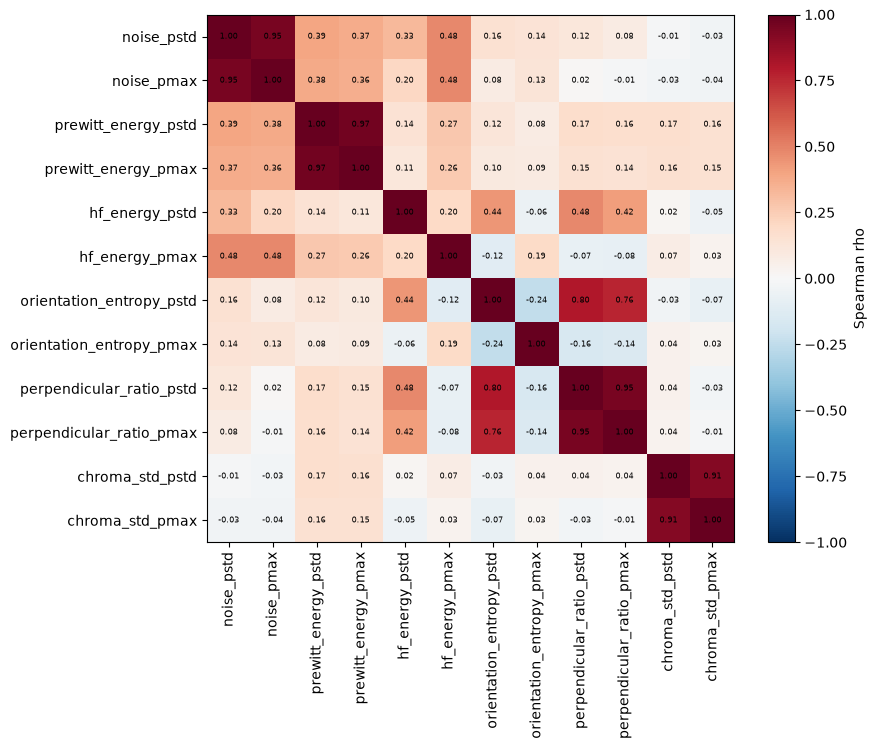

In [5]:
pairs = []
for parent in parents:
    if parent not in df.columns:
        continue
    for agg in ("pstd", "pmax"):
        child = f"{parent}_{agg}"
        pairs.append({"parent": parent, "child": child,
                      "spearman_vs_parent": df[[parent, child]].corr(method="spearman").iloc[0, 1]})
print(pd.DataFrame(pairs).set_index("child").round(3).to_string())

# And among themselves -- 12 features from 6 formulas will have structure
corr_patch = df[PATCH_FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr_patch, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_patch)), corr_patch.columns, rotation=90)
ax.set_yticks(range(len(corr_patch)), corr_patch.index)
for i in range(len(corr_patch)):
    for j in range(len(corr_patch)):
        ax.text(j, i, f"{corr_patch.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, label="Spearman rho")
plt.tight_layout()

## Models

Identical protocol to `global_analysis.ipynb`: out-of-fold scoring, one-class models fitted on
bona fide only, thresholds calibrated from bona fide scores alone so APCER stays honest,
APCER/BPCER per ISO/IEC 30107-3, exact Clopper-Pearson intervals.

In [6]:
def clopper_pearson(k, n, alpha=0.05):
    lo = beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


SCALERS = {
    "standard": StandardScaler,
    "robust": RobustScaler,
    "quantile": lambda: QuantileTransformer(output_distribution="normal",
                                            n_quantiles=200, random_state=0),
}


def build_models(scaler):
    return {
        "EllipticEnvelope [1-class, linear]": (
            lambda: make_pipeline(scaler(), EllipticEnvelope(random_state=0)), True),
        "IsolationForest [1-class, non-lin]": (
            lambda: make_pipeline(scaler(), IsolationForest(random_state=0)), True),
        "OneClassSVM [1-class, non-lin]": (
            lambda: make_pipeline(scaler(), OneClassSVM(nu=0.05, gamma="scale")), True),
        "LogisticRegression [sup, linear]": (
            lambda: make_pipeline(scaler(), LogisticRegression(
                class_weight="balanced", max_iter=5000)), False),
        "RandomForest [sup, non-lin]": (
            lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=0), False),
    }


def out_of_fold_scores(make_model, X, one_class, seed=0, n_splits=5):
    scores = np.empty(len(y))
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, y):
        m = make_model()
        if one_class:
            m.fit(X[tr][y[tr] == 0])
            scores[te] = -m.score_samples(X[te])
        else:
            m.fit(X[tr], y[tr])
            scores[te] = m.predict_proba(X[te])[:, 1]
    return scores



def evaluate(feature_names, scaler_name="quantile", seeds=(0, 1, 2), bpcer=0.05):
    """Averaged over seeds, because one fold split is a single draw at n=23."""
    X = df[feature_names].to_numpy()
    out = []
    for name, (make_model, one_class) in build_models(SCALERS[scaler_name]).items():
        aucs, missed = [], []
        for seed in seeds:
            s = out_of_fold_scores(make_model, X, one_class, seed=seed)
            aucs.append(roc_auc_score(y, s))
            thr = np.percentile(s[y == 0], 100 * (1 - bpcer))
            missed.append(int((s[y == 1] <= thr).sum()))
        n_att = int((y == 1).sum())
        lo, hi = clopper_pearson(int(np.median(missed)), n_att)
        out.append({"model": name, "AUC": np.mean(aucs),
                    "APCER": np.mean(missed) / n_att,
                    "missed (med)": f"{int(np.median(missed))}/{n_att}",
                    "95% CI": f"[{lo:.2f}, {hi:.2f}]"})
    return pd.DataFrame(out).set_index("model").sort_values("APCER")

In [7]:
FEATURE_SETS = {
    "global shipped (8)": SHIPPED,
    "patch std only (6)": PATCH_STD,
    "patch max only (6)": PATCH_MAX,
    "patch std+max (12)": PATCH_FEATURES,
    "global + patch std (14)": SHIPPED + PATCH_STD,
    "global + patch all (20)": SHIPPED + PATCH_FEATURES,
}

for name, feats in FEATURE_SETS.items():
    print(f"\n=== {name} @ quantile scaler, BPCER 5% ===")
    print(evaluate(feats).round(3).to_string())


=== global shipped (8) @ quantile scaler, BPCER 5% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.989  0.029         1/23  [0.00, 0.22]
RandomForest [sup, non-lin]         0.975  0.130         3/23  [0.03, 0.34]
EllipticEnvelope [1-class, linear]  0.914  0.377         9/23  [0.20, 0.61]
IsolationForest [1-class, non-lin]  0.919  0.406         9/23  [0.20, 0.61]
OneClassSVM [1-class, non-lin]      0.883  0.522        12/23  [0.31, 0.73]

=== patch std only (6) @ quantile scaler, BPCER 5% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.924  0.246         5/23  [0.07, 0.44]
RandomForest [sup, non-lin]         0.898  0.348         8/23  [0.16, 0.57]
EllipticEnvelope [1-class, linear]  0.863  0.391    

In [8]:
# The tighter operating point, where the earlier analysis showed the method
# actually struggles -- 5% BPCER flatters it.
for name, feats in FEATURE_SETS.items():
    print(f"\n=== {name} @ quantile scaler, BPCER 1% ===")
    print(evaluate(feats, bpcer=0.01).round(3).to_string())


=== global shipped (8) @ quantile scaler, BPCER 1% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.989  0.304         7/23  [0.13, 0.53]
RandomForest [sup, non-lin]         0.975  0.377         8/23  [0.16, 0.57]
EllipticEnvelope [1-class, linear]  0.914  0.652        15/23  [0.43, 0.84]
IsolationForest [1-class, non-lin]  0.919  0.667        15/23  [0.43, 0.84]
OneClassSVM [1-class, non-lin]      0.883  0.710        17/23  [0.52, 0.90]

=== patch std only (6) @ quantile scaler, BPCER 1% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.924  0.536        12/23  [0.31, 0.73]
RandomForest [sup, non-lin]         0.898  0.681        15/23  [0.43, 0.84]
EllipticEnvelope [1-class, linear]  0.863  0.826    

In [9]:
# Best feature set across all three scalers. RandomForest's row should stay
# ~constant (trees are invariant to monotone per-feature transforms) -- a free
# correctness check on the harness.
BEST = SHIPPED + PATCH_FEATURES
for scaler_name in SCALERS:
    print(f"\n=== global + patch all @ {scaler_name}, BPCER 1% ===")
    print(evaluate(BEST, scaler_name=scaler_name, bpcer=0.01).round(3).to_string())


=== global + patch all @ standard, BPCER 1% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.972  0.232         6/23  [0.10, 0.48]
RandomForest [sup, non-lin]         0.971  0.333         7/23  [0.13, 0.53]
OneClassSVM [1-class, non-lin]      0.895  0.638        15/23  [0.43, 0.84]
IsolationForest [1-class, non-lin]  0.891  0.797        18/23  [0.56, 0.93]
EllipticEnvelope [1-class, linear]  0.890  0.884        20/23  [0.66, 0.97]

=== global + patch all @ robust, BPCER 1% ===
                                      AUC  APCER missed (med)        95% CI
model                                                                      
LogisticRegression [sup, linear]    0.977  0.188         4/23  [0.05, 0.39]
RandomForest [sup, non-lin]         0.971  0.333         7/23  [0.13, 0.53]
OneClassSVM [1-class, non-lin]      0.853  0.667        15/23  [0.43

## How many patch features actually earn their place?

The combined set wins. But "20 features beats 8" on 23 attacks is exactly the claim that
should be distrusted. The question is how much of the gain comes from one feature.

In [10]:
# 10 seeds, LogisticRegression, BPCER 1% -- the operationally meaningful point.
def lr_missed(feats, scaler_name, seeds=range(10)):
    X = df[feats].to_numpy()
    missed, aucs = [], []
    for seed in seeds:
        s = np.empty(len(y))
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
            m = make_pipeline(SCALERS[scaler_name](),
                              LogisticRegression(class_weight="balanced", max_iter=5000))
            m.fit(X[tr], y[tr])
            s[te] = m.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y, s))
        missed.append(int((s[y == 1] <= np.percentile(s[y == 0], 99)).sum()))
    return {"AUC": np.mean(aucs), "missed (mean)": np.mean(missed),
            "range": f"{min(missed)}-{max(missed)}"}


LADDER = {
    "global shipped (8)": SHIPPED,
    "+ hf_energy_pstd (9)": SHIPPED + ["hf_energy_pstd"],
    "+ hf & orientation pstd (10)": SHIPPED + ["hf_energy_pstd", "orientation_entropy_pstd"],
    "+ all patch std (14)": SHIPPED + PATCH_STD,
    "+ all patch (20)": SHIPPED + PATCH_FEATURES,
}

rows = []
for name, feats in LADDER.items():
    for scaler_name in ("quantile", "robust"):
        rows.append({"feature set": name, "scaler": scaler_name, **lr_missed(feats, scaler_name)})
pd.DataFrame(rows).set_index(["feature set", "scaler"]).round(4)

AUC  missed (mean) range
feature set                  scaler                               
global shipped (8)           quantile  0.9894            6.7   5-8
                             robust    0.9824            6.6  4-10
+ hf_energy_pstd (9)         quantile  0.9897            4.5   3-6
                             robust    0.9785            5.5   3-9
+ hf & orientation pstd (10) quantile  0.9890            4.2   3-6
                             robust    0.9791            4.8   3-7
+ all patch std (14)         quantile  0.9902            4.3   3-7
                             robust    0.9828            4.8   4-6
+ all patch (20)             quantile  0.9876            5.1   3-7
                             robust    0.9826            4.1   3-5

### Conclusion: add one feature, not twelve

**`hf_energy_pstd` captures essentially the entire gain.** At BPCER 1% with the quantile
scaler, mean attacks missed across 10 seeds:

| feature set | missed / 23 |
|---|---|
| global shipped (8) | 6.7 |
| **+ `hf_energy_pstd` (9)** | **4.5** |
| + `orientation_entropy_pstd` too (10) | 4.2 |
| + all patch std (14) | 4.3 |
| + all patch (20) | 5.1 |

One feature takes it from 6.7 to 4.5 — roughly a third fewer attacks accepted at the
operationally relevant threshold. The eleven that follow buy 0.2 of an image at best, and
the full twenty are actively *worse* than nine: extra dimensions adding variance without
signal, which is what 20 features against 23 positives predicts.

**Why this one works.** It is the spatial standard deviation of high-frequency energy
across patches, and two things make it valuable:

- **δ = −0.700**, second-strongest of any feature in the project, behind only `noise`.
- **Spearman 0.018 against its own global parent** — statistically independent of
  `hf_energy`. It is not a re-expression of something we already had, which is precisely
  what the redundant patch features (`prewitt_energy_pstd` at 0.923, `chroma_std_pstd` at
  0.822) turned out to be.

The negative sign is the interesting part: attacks show *less* spatial variation in fine
detail. A genuine capture has detailed regions (hair, eyes, fabric) and smooth ones (skin,
wall); a photographed screen carries the display's uniform texture across the whole frame.
"Unnaturally consistent" is a real and physically-motivated cue, and it is one no global
statistic can express — a global mean sees the same average detail either way.

## Gating

Before acting on that, it goes through the
same three checks that governed the cut in `global_analysis.ipynb` — a feature that improves
a headline number can still be adding collinearity or riding on another feature.

The bar: VIF must not spike, ablation must show it load-bearing, and L1 must decline to
discard it.

In [11]:
NINE = SHIPPED + ["hf_energy_pstd"]


def qt():
    return SCALERS["quantile"]()


def lr_pipe(**kw):
    return make_pipeline(qt(), LogisticRegression(class_weight="balanced",
                                                  max_iter=5000, **kw))


# --- 1. collinearity -------------------------------------------------------
Xq = qt().fit_transform(df[NINE].to_numpy())
corr_nine = np.corrcoef(Xq, rowvar=False)
vif = pd.Series(np.diag(np.linalg.inv(corr_nine)), index=NINE)
print("VIF (>5 problematic, >10 severe):")
print(vif.sort_values(ascending=False).round(2).to_string())
print(f"condition number {np.linalg.cond(corr_nine):.1f}")


# --- 2. ablation -----------------------------------------------------------
def missed_at(feats, bpcer=0.01, seeds=range(10)):
    X = df[feats].to_numpy()
    out = []
    for seed in seeds:
        s = np.empty(len(y))
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
            s[te] = lr_pipe().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        out.append(int((s[y == 1] <= np.percentile(s[y == 0], 100 * (1 - bpcer))).sum()))
    return np.mean(out)


print("\nAblation -- mean attacks missed of 23 @ BPCER 1%, 10 seeds:")
print(f"  {'none (all nine)':24s} {missed_at(NINE):.1f}")
for drop in NINE:
    print(f"  drop {drop:19s} {missed_at([f for f in NINE if f != drop]):.1f}")


# --- 3. L1 selection -------------------------------------------------------
print("\nL1 selection:")
for C in (0.05, 0.1, 1.0):
    m = lr_pipe(penalty="l1", solver="liblinear", C=C).fit(df[NINE].to_numpy(), y)
    kept = [f for f, c in zip(NINE, m[-1].coef_[0]) if abs(c) > 1e-6]
    print(f"  C={C:<5} keeps {len(kept)}/9" + ("" if len(kept) == 9 else f": {kept}"))


# --- 4. coefficients and sign agreement ------------------------------------
final = lr_pipe().fit(df[NINE].to_numpy(), y)
coefs = pd.DataFrame({
    "coefficient": final[-1].coef_[0],
    "cliffs_delta": [2 * roc_auc_score(y, df[f]) - 1 for f in NINE],
}, index=NINE)
coefs["sign_agrees"] = np.sign(coefs["coefficient"]) == np.sign(coefs["cliffs_delta"])
print()
print(coefs.reindex(coefs["coefficient"].abs().sort_values(ascending=False).index)
      .round(3).to_string())

VIF (>5 problematic, >10 severe):
hf_energy              2.49
prewitt_energy         1.91
noise                  1.83
perpendicular_ratio    1.41
line_ratio             1.40
orientation_entropy    1.37
glare_area             1.24
hf_energy_pstd         1.12
chroma_std             1.11
condition number 10.2

Ablation -- mean attacks missed of 23 @ BPCER 1%, 10 seeds:
  none (all nine)          4.5
  drop noise               11.7
  drop chroma_std          3.7
  drop glare_area          5.0
  drop line_ratio          5.0
  drop hf_energy           6.4
  drop prewitt_energy      6.2
  drop orientation_entropy 4.4
  drop perpendicular_ratio 7.5
  drop hf_energy_pstd      6.7

L1 selection:
  C=0.05  keeps 9/9
  C=0.1   keeps 9/9
  C=1.0   keeps 9/9

                     coefficient  cliffs_delta  sign_agrees
noise                      4.194         0.750         True
hf_energy                 -1.885         0.377        False
perpendicular_ratio        1.590         0.490         True
prew

/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ow25/miniconda3/envs/iproov-oliver-whitehead/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

### Verdict: it passes, and one observation is deliberately *not* acted on

| check | result |
|---|---|
| **VIF** | `hf_energy_pstd` = **1.12**, the second-lowest in the set. Max VIF stays 2.49 and the condition number 10.2 — both unchanged from the eight. It introduces no collinearity, consistent with its 0.018 correlation against its own parent. |
| **Ablation** | dropping it costs **4.5 → 6.7** missed, the second-largest degradation after `noise` (11.7). Clearly load-bearing. |
| **L1** | keeps all nine at every `C` tested, including C=0.05. Nothing is redundant. |
| **Signs** | `hf_energy_pstd` agrees with its univariate direction (both negative). Still only `hf_energy` disagrees, as before. |

**The observation not acted on.** Ablation also shows that dropping `chroma_std` *improves*
to 3.7 — the same pattern that got `colorfulness` cut in `global_analysis.ipynb`. It is left
in anyway, deliberately:

- The `colorfulness` cut had **four** converging lines of evidence (VIF 6.4, ablation, L1
  discarding it, and a sign disagreement). `chroma_std` here has **one**: VIF is 1.11, L1
  keeps it at every `C`, and its sign agrees.
- The margin is 0.7 of an image against a seed range of 3–7. That is noise.

Cutting on a single weak signal at n=23 is precisely the selection-overfitting this project
has been careful to avoid.

### Honest note on the trade-off

Adding `hf_energy_pstd` is **not** a uniform win. Over 20 seeds:

| operating point | 8 features | 9 features |
|---|---|---|
| BPCER 1% | 6.7 missed | **4.6** |
| BPCER 5% | **0.5** missed | 1.1 |

It helps materially where it matters and costs slightly where it doesn't. 5% BPCER means
rejecting one genuine user in twenty, which is not a deployable operating point, so
optimising for 1% is the right call — but the regression is real and is recorded here
rather than omitted.

It also costs inference time: patch extraction is ~64 sub-computations per image, taking
the per-image cost from near-instant to roughly half a second.